In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhuvankumarapatri/brain-tumor")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/bhuvankumarapatri/brain-tumor


In [2]:
import os
import numpy as np
import torch
from torch import amp
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torchvision.models import swin_t, Swin_T_Weights
from torch.utils.data import DataLoader, random_split, Subset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    matthews_corrcoef,
    average_precision_score
)
from sklearn.preprocessing import label_binarize
from scipy.stats import ttest_rel

from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 🔥 Better for performance + AO
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

In [3]:
DATA_DIR = os.path.join(path, "Training")
TEST_DIR = os.path.join(path, "Testing")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# load WITHOUT transform
full_dataset = datasets.ImageFolder(DATA_DIR)
num_classes = len(full_dataset.classes)

labels = full_dataset.targets

# stratified split
train_idx, val_idx = train_test_split(
    np.arange(len(labels)),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

#  separate transforms
train_ds = Subset(
    datasets.ImageFolder(DATA_DIR, transform=train_transform),
    train_idx
)

val_ds = Subset(
    datasets.ImageFolder(DATA_DIR, transform=test_transform),
    val_idx
)

test_ds = datasets.ImageFolder(TEST_DIR, transform=test_transform)

print("Classes:", full_dataset.classes)
print(len(train_ds), len(val_ds), len(test_ds))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
4569 1143 1311


In [5]:
base_swin = swin_t(weights=Swin_T_Weights.DEFAULT)

def build_swin(dropout, num_classes):
    import copy
    model = copy.deepcopy(base_swin)  # reuse weights

    in_features = model.head.in_features
    model.head = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )

    return model.to(device)

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 177MB/s]  


In [6]:
# Initialize once at the top
scaler = amp.GradScaler()

# Pass the scaler as an argument to make it flexible
def quick_train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        with amp.autocast(device_type='cuda'):
            output = model(x)
            loss = criterion(output, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

def evaluate_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.inference_mode():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with amp.autocast(device_type='cuda'):
                output = model(x)
                pred = output.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

def evaluate(model, loader):
    model.eval()
    y_true, y_pred, y_score = [], [], []
    
    with torch.inference_mode():
        for x, y in loader:
            x = x.to(device)

            # AMP forward
            with amp.autocast(device_type='cuda'):
                out = model(x)

            # Softmax (stable + detached)
            probs = torch.softmax(out, dim=1).detach().cpu().numpy()
            y_score.extend(probs)

            preds = out.argmax(dim=1)
            y_pred.extend(preds.cpu().numpy())

            y_true.extend(y.cpu().numpy())

    final_acc = np.mean(np.array(y_true) == np.array(y_pred))

    return final_acc, np.array(y_pred), np.array(y_true), np.array(y_score)

In [7]:
from math import gamma, sin, pi

def levy_flight(dim):
    beta = 1.5
    sigma = (gamma(1 + beta) * sin(pi * beta / 2) /
             (gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2))) ** (1 / beta)

    u = np.random.randn(dim) * sigma
    v = np.random.randn(dim)

    return u / (np.abs(v) ** (1 / beta))

In [8]:
def objective_swin(params):
    # ------------------------------
    # 1. Parameter Mapping
    # ------------------------------
    lr = 10 ** float(params[0])
    dropout = float(params[1])
    batch = int(round(params[2] / 8)) * 8   # GPU-friendly
    batch = max(16, min(64, batch))

    # ------------------------------
    # 2. DataLoader Setup
    # ------------------------------
    is_cuda = (device.type == "cuda")

    train_loader = DataLoader(
        train_ds,
        batch_size=batch,
        shuffle=True,
        num_workers=2,
        pin_memory=is_cuda
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch,
        shuffle=False,
        num_workers=2,
        pin_memory=is_cuda
    )

    # ------------------------------
    # 3. Model + Optimizer + Scaler
    # ------------------------------
    model = build_swin(dropout, num_classes)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    scaler = amp.GradScaler()   # 🔥 independent per candidate

    # ------------------------------
    # 4. 3-Epoch Fitness Training
    # ------------------------------
    for _ in range(3):
        quick_train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler
        )

    # ------------------------------
    # 5. Validation Accuracy
    # ------------------------------
    acc = evaluate_accuracy(model, val_loader)

    # ------------------------------
    # 6. Memory Cleanup
    # ------------------------------
    del model, optimizer, train_loader, val_loader, scaler
    import gc
    gc.collect()
    torch.cuda.empty_cache()

    return acc

In [9]:
class AquilaOptimizer:
    def __init__(self, obj_func, bounds, pop_size=10, max_iter=12):
        self.obj_func = obj_func
        self.bounds = bounds
        self.pop_size = pop_size
        self.max_iter = max_iter

    def optimize(self):
        dim = len(self.bounds)

        lb = np.array([b[0] for b in self.bounds])
        ub = np.array([b[1] for b in self.bounds])

        X = np.random.rand(self.pop_size, dim) * (ub - lb) + lb
        fitness = np.zeros(self.pop_size)

        print("\n🔹 Initial Population Evaluation")
        for i in range(self.pop_size):
            fitness[i] = self.obj_func(X[i])
            print(f"Candidate {i+1}: Acc={fitness[i]:.4f}")

        best_idx = np.argmax(fitness)
        X_best = X[best_idx].copy()
        best_fit = fitness[best_idx]

        print(f"\n✅ Initial Best: {best_fit:.4f}")

        for t in tqdm(range(self.max_iter), desc="Aquila Optimization"):

            X_mean = np.mean(X, axis=0)

            for i in range(self.pop_size):

                r = np.random.rand()
                T_ratio = t / self.max_iter

                QF = (t+1)**((2*np.random.rand()-1) / ((1-self.max_iter)**2 + 1e-9))
                G1 = 2*np.random.rand() - 1
                G2 = 2*(1 - t/self.max_iter)

                if T_ratio <= (2/3):

                    if r <= 0.5:
                        # X1
                        X_new = X_best*(1 - t/self.max_iter) + \
                                (X_mean - X_best)*np.random.rand(dim)

                    else:
                        # X2
                        LF = levy_flight(dim)
                        XR = X[np.random.randint(self.pop_size)]

                        theta = np.random.rand()*2*np.pi
                        r_spiral = np.random.rand()

                        x = r_spiral*np.sin(theta)
                        y = r_spiral*np.cos(theta)

                        X_new = X_best*LF + XR + (y - x)*np.random.rand(dim)

                else:

                    if r <= 0.5:
                        # X3
                        alpha = 0.1
                        delta = 0.1

                        X_new = (X_best - X_mean)*alpha - np.random.rand(dim) + \
                                ((ub - lb)*np.random.rand(dim) + lb)*delta

                    else:
                        # X4
                        LF = levy_flight(dim)

                        X_new = QF*X_best - \
                                (G1*X[i]*np.random.rand(dim)) - \
                                (G2*LF + np.random.rand(dim)*G1)

                X_new = np.clip(X_new, lb, ub)

                new_fit = self.obj_func(X_new)

                if new_fit > fitness[i]:
                    X[i] = X_new
                    fitness[i] = new_fit

                if new_fit > best_fit:
                    best_fit = new_fit
                    X_best = X_new.copy()
                    print(f"🔥 NEW BEST: {best_fit:.4f}")

        print("\n🏆 FINAL BEST")
        print(X_best, best_fit)

        return X_best, best_fit


# 🔹 UPDATED BOUNDS (IMPORTANT)
bounds = [
    (-5, -3),    # log10 LR
    (0.1, 0.4),
    (16, 48)
]

ao = AquilaOptimizer(objective_swin, bounds)
best_params, best_acc = ao.optimize()

best_lr = 10 ** best_params[0]
best_dropout = best_params[1]
best_batch_size = int(best_params[2])

print("\n🎯 FINAL OUTPUT")
print(best_lr, best_dropout, best_batch_size, best_acc)


🔹 Initial Population Evaluation
Candidate 1: Acc=0.9799
Candidate 2: Acc=0.9755
Candidate 3: Acc=0.9729
Candidate 4: Acc=0.9746
Candidate 5: Acc=0.8688
Candidate 6: Acc=0.9764
Candidate 7: Acc=0.9738
Candidate 8: Acc=0.9554
Candidate 9: Acc=0.9729
Candidate 10: Acc=0.9711

✅ Initial Best: 0.9799


Aquila Optimization:   8%|▊         | 1/12 [17:31<3:12:49, 1051.74s/it]

🔥 NEW BEST: 0.9816


Aquila Optimization: 100%|██████████| 12/12 [3:26:52<00:00, 1034.38s/it] 


🏆 FINAL BEST
[-3.77541046  0.16580927 29.36241583] 0.9816272965879265

🎯 FINAL OUTPUT
0.00016772180961964223 0.16580926811611277 29 0.9816272965879265


In [10]:
model_cnx = build_swin(best_dropout, num_classes).to(device)

# 2. Define ALL Loaders with Optimized Batch Size
train_loader = DataLoader(train_ds, batch_size=best_batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=best_batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=best_batch_size, shuffle=False, num_workers=2, pin_memory=True)

# 3. Initialize Final Training Objects
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_cnx.parameters(), lr=best_lr)

In [11]:
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

best_val_acc = 0
patience = 5
counter = 0

scaler = amp.GradScaler()

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

for epoch in range(20):
    model_cnx.train()
    run_loss, correct, total = 0, 0, 0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/20"):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)

        with amp.autocast(device_type='cuda'):
            out = model_cnx(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        run_loss += loss.item() * x.size(0)
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    scheduler.step()

    train_loss = run_loss / total
    train_acc = correct / total

    # ---------- VALIDATION ----------
    model_cnx.eval()
    v_loss, v_corr, v_tot = 0, 0, 0

    with torch.inference_mode():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            with amp.autocast(device_type='cuda'):
                out = model_cnx(x)
                loss = criterion(out, y)

            v_loss += loss.item() * x.size(0)
            pred = out.argmax(1)
            v_corr += (pred == y).sum().item()
            v_tot += y.size(0)

    val_loss = v_loss / v_tot
    val_acc = v_corr / v_tot

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1} | Train {train_acc:.4f} | Val {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0
        torch.save(model_cnx.state_dict(), "final_swin_aq.pth")
        print("✅ Best model saved")
    else:
        counter += 1

    if counter >= patience:
        print("🛑 Early stopping triggered")
        break

# Load best
model_cnx.load_state_dict(torch.load("final_swin_aq.pth", map_location=device))
model_cnx.eval()

Epoch 1/20: 100%|██████████| 158/158 [00:34<00:00,  4.63it/s]


Epoch 1 | Train 0.8601 | Val 0.9370
✅ Best model saved


Epoch 2/20: 100%|██████████| 158/158 [00:32<00:00,  4.93it/s]


Epoch 2 | Train 0.9547 | Val 0.9781
✅ Best model saved


Epoch 3/20: 100%|██████████| 158/158 [00:32<00:00,  4.84it/s]


...

Epoch 18/20: 100%|██████████| 158/158 [00:32<00:00,  4.92it/s]


Epoch 18 | Train 0.9989 | Val 0.9948


Epoch 19/20: 100%|██████████| 158/158 [00:32<00:00,  4.93it/s]


Epoch 19 | Train 0.9993 | Val 0.9930
🛑 Early stopping triggered


SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock(
       

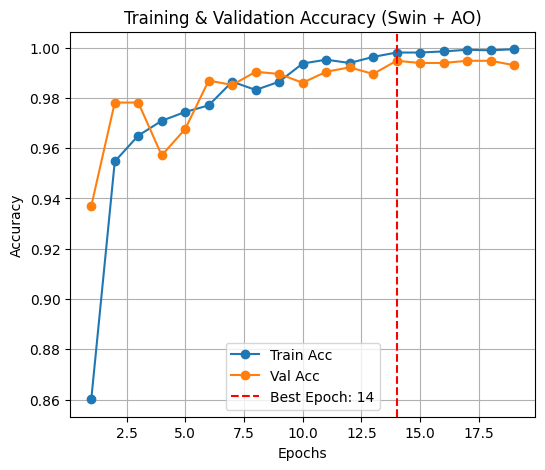

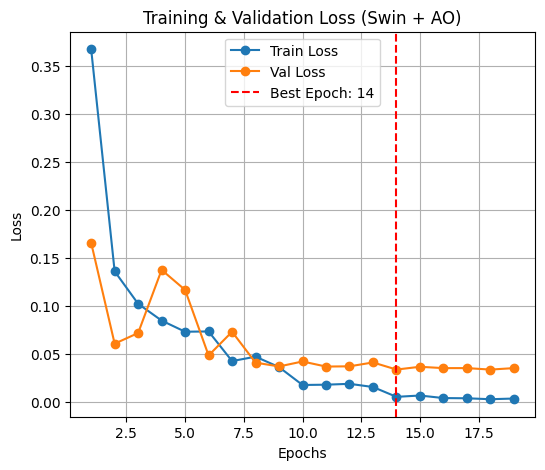

In [12]:
# Accuracy & Loss plots
epochs_range = range(1, len(history["train_acc"])+1)

# Determine best epoch
best_epoch = history["val_acc"].index(max(history["val_acc"])) + 1

# -----------------------
# Accuracy plot
# -----------------------
plt.figure(figsize=(6,5))
plt.plot(epochs_range, history["train_acc"], marker='o', label="Train Acc")
plt.plot(epochs_range, history["val_acc"], marker='o', label="Val Acc")
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f"Best Epoch: {best_epoch}")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy (Swin + AO)")
plt.legend()
plt.grid(True)
plt.savefig("accuracy_plot.png", dpi=300)
plt.show()

# -----------------------
# Loss plot
# -----------------------
plt.figure(figsize=(6,5))
plt.plot(epochs_range, history["train_loss"], marker='o', label="Train Loss")
plt.plot(epochs_range, history["val_loss"], marker='o', label="Val Loss")
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f"Best Epoch: {best_epoch}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Swin + AO)")
plt.legend()
plt.grid(True)
plt.savefig("loss_plot.png", dpi=300)
plt.show()


Swin + AO Test Accuracy: 0.9962

=== Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9966    0.9900    0.9933       300
  meningioma     0.9871    1.0000    0.9935       306
     notumor     1.0000    0.9975    0.9988       405
   pituitary     1.0000    0.9967    0.9983       300

    accuracy                         0.9962      1311
   macro avg     0.9959    0.9960    0.9960      1311
weighted avg     0.9962    0.9962    0.9962      1311



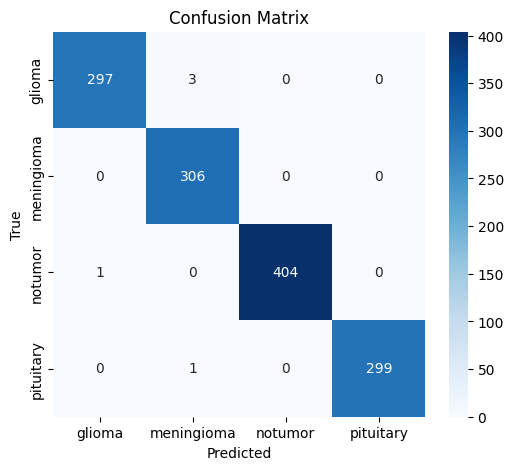


MCC: 0.9949
mAP: 0.9995


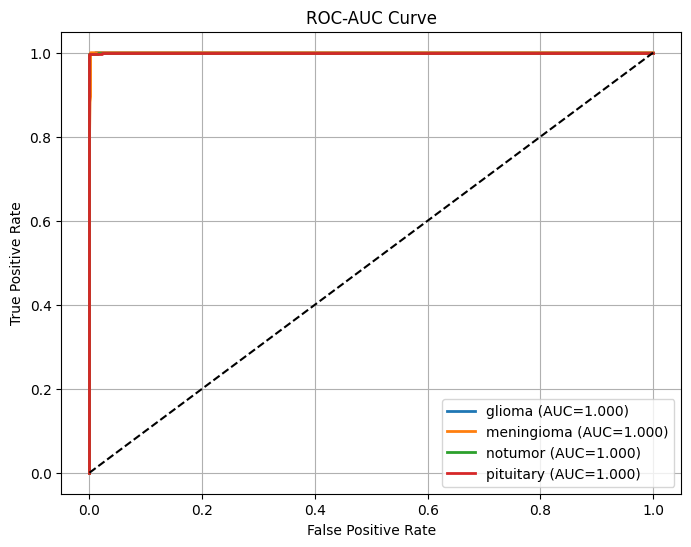

In [14]:
# ------------------------------
# Load Best Model (AO)
# ------------------------------
model_cnx.load_state_dict(torch.load("final_swin_aq.pth", map_location=device))
model_cnx.eval()

torch.cuda.empty_cache()

# ------------------------------
# Evaluate
# ------------------------------
acc, y_pred, y_true, y_score = evaluate(model_cnx, test_loader)

print(f"Swin + AO Test Accuracy: {acc:.4f}")

print("\n=== Classification Report ===")
print(classification_report(
    y_true,
    y_pred,
    target_names=full_dataset.classes,
    digits=4
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

mcc = matthews_corrcoef(y_true, y_pred)
print(f"\nMCC: {mcc:.4f}")

y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
mAP = average_precision_score(y_true_bin, y_score, average="macro")
print(f"mAP: {mAP:.4f}")

plt.figure(figsize=(8,6))
for i, cls in enumerate(full_dataset.classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Load the best checkpoint
best_model_state = torch.load("final_swin_aq.pth", map_location=device)

# Create the target directory if it doesn't exist
output_dir = "/kaggle/working"
os.makedirs(output_dir, exist_ok=True)

# Save it with a new filename
torch.save(best_model_state, os.path.join(output_dir, "final_swin_aq.pth"))
print("✅ Best model saved as final_swin_aq.pth")

✅ Best model saved as final_swin_aq.pth
